In [23]:
from sklearn.datasets import load_breast_cancer
bc = load_breast_cancer()

In [24]:
bc

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
bc.data, bc.target, test_size=0.2, random_state=0)

In [26]:
dtree = DecisionTreeClassifier(random_state=0)
dtree.fit(X_train, y_train)

accuracy = dtree.score(X_test, y_test)
accuracy

0.9122807017543859

In [27]:
scores = []

for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        bc.data, bc.target, test_size=0.1, random_state=i
    )
    DecisionTreeClassifier(random_state=i).fit(X_train, y_train)
    scores.append(dtree.score(X_test, y_test))

scores = np.array(scores)

mean_score = scores.mean()
std_dev = scores.std()
std_error = std_dev / np.sqrt(len(scores))

mean_score, std_dev, std_error

(0.9736842105263157, 0.030639033678198223, 0.009688913172971284)

In [28]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
import numpy as np

In [29]:
dtree = DecisionTreeClassifier(random_state=0)
cv_scores = cross_val_score(dtree, bc.data, bc.target, cv=10)
cv_scores.mean(), cv_scores.std()

(0.9174498746867167, 0.03325033066158844)

In [30]:
from sklearn.model_selection import KFold

In [31]:
X = bc.data

In [32]:
Y = bc.target

In [33]:
help(cross_val_score)

Help on function cross_val_score in module sklearn.model_selection._validation:

cross_val_score(estimator, X, y=None, *, groups=None, scoring=None, cv=None, n_jobs=None, verbose=0, fit_params=None, params=None, pre_dispatch='2*n_jobs', error_score=nan)
    Evaluate a score by cross-validation.

    Read more in the :ref:`User Guide <cross_validation>`.

    Parameters
    ----------
    estimator : estimator object implementing 'fit'
        The object to use to fit the data.

    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        The data to fit. Can be for example a list, or an array.

    y : array-like of shape (n_samples,) or (n_samples, n_outputs),             default=None
        The target variable to try to predict in the case of
        supervised learning.

    groups : array-like of shape (n_samples,), default=None
        Group labels for the samples used while splitting the dataset into
        train/test set. Only used in conjunction with a "Group"

In [34]:
kf = KFold(n_splits=5)

In [35]:
kf.get_n_splits(X)

5

In [36]:
a = kf.split(bc.data)

In [37]:
for train_index, test_index in kf.split(bc.data):
    print(train_index, test_index)

[114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131
 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149
 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167
 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185
 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203
 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221
 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239
 240 241 242 243 244 245 246 247 248 249 250 251 252 253 254 255 256 257
 258 259 260 261 262 263 264 265 266 267 268 269 270 271 272 273 274 275
 276 277 278 279 280 281 282 283 284 285 286 287 288 289 290 291 292 293
 294 295 296 297 298 299 300 301 302 303 304 305 306 307 308 309 310 311
 312 313 314 315 316 317 318 319 320 321 322 323 324 325 326 327 328 329
 330 331 332 333 334 335 336 337 338 339 340 341 342 343 344 345 346 347
 348 349 350 351 352 353 354 355 356 357 358 359 36

In [38]:
bc.data

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]])

In [39]:
bc.data.shape

(569, 30)

In [59]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold
import numpy as np

kf = KFold(n_splits=10, shuffle=True, random_state=0)

# Store scores and metrics
scores = []

for fold_number, (train_index, test_index) in enumerate(kf.split(bc.data), 1):
    X_train, X_test = bc.data[train_index], bc.data[test_index]
    y_train, y_test = bc.target[train_index], bc.target[test_index]

    dtree = DecisionTreeClassifier(random_state=0)
    dtree.fit(X_train, y_train)

    # Accuracy
    accuracy = dtree.score(X_test, y_test)
    scores.append(accuracy)

    # Initialize confusion matrix counts
    TP = FP = TN = FN = 0

    # Compute TP, FP, TN, FN
    for x, y in zip(X_test, y_test):
        prediction = dtree.predict([x])[0]  # predict returns array
        if prediction == 1 and y == 1:
            TP += 1
        elif prediction == 1 and y == 0:
            FP += 1
        elif prediction == 0 and y == 0:
            TN += 1
        elif prediction == 0 and y == 1:
            FN += 1

    # Build confusion matrix in standard format
    confusion_matrix = [[TN, FP],
                        [FN, TP]]

    # Compute metrics
    Precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    Recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    F1_Score = 2 * (Precision * Recall) / (Precision + Recall) if (Precision + Recall) != 0 else 0

    # Print nicely
    print(f"Fold {fold_number}:")
    print("Confusion Matrix:")
    print(f"          Pred 0   Pred 1")
    print(f"True 0    {TN:5}   {FP:5}")
    print(f"True 1    {FN:5}   {TP:5}")
    print(f"Precision: {Precision:.2f}, Recall: {Recall:.2f}, F1: {F1_Score:.2f}")
    print(f"Accuracy: {accuracy:.2f}")
    print("-" * 40)

# Optional: mean accuracy over all folds
scores = np.array(scores)
print(f"Mean accuracy: {scores.mean():.2f}, Std: {scores.std():.2f}")

Fold 1:
Confusion Matrix:
          Pred 0   Pred 1
True 0       21       1
True 1        6      29
Precision: 0.97, Recall: 0.83, F1: 0.89
Accuracy: 0.88
----------------------------------------
Fold 2:
Confusion Matrix:
          Pred 0   Pred 1
True 0       22       3
True 1        6      26
Precision: 0.90, Recall: 0.81, F1: 0.85
Accuracy: 0.84
----------------------------------------
Fold 3:
Confusion Matrix:
          Pred 0   Pred 1
True 0       15       1
True 1        6      35
Precision: 0.97, Recall: 0.85, F1: 0.91
Accuracy: 0.88
----------------------------------------
Fold 4:
Confusion Matrix:
          Pred 0   Pred 1
True 0       20       0
True 1        0      37
Precision: 1.00, Recall: 1.00, F1: 1.00
Accuracy: 1.00
----------------------------------------
Fold 5:
Confusion Matrix:
          Pred 0   Pred 1
True 0       15       3
True 1        1      38
Precision: 0.93, Recall: 0.97, F1: 0.95
Accuracy: 0.93
----------------------------------------
Fold 6:
Confusion Ma

In [61]:
from sklearn import metrics
cv_scores = cross_val_score(dtree, bc.data, bc.target, cv = 5)
print(cv_scores.mean())
print(cv_scores.std())

0.9173730787144851
0.01641972426994943


In [63]:
from sklearn.neighbors import KNeighborsClassifier
my_neigh = KNeighborsClassifier(n_neighbors=5)

In [79]:
my_neigh.fit(X_train,y_train)
my_neigh.score(X_test,y_test)
scores = []
cv = cross_val_score(my_neigh,bc.data,bc.target,cv=5)
scores.append(cv.mean())
scores

[0.9279459711224964]

In [95]:
my_neigh.predict_proba(X_test)[:,0]

array([0.6, 1. , 1. , 0.8, 1. , 1. , 1. , 1. , 1. , 0. , 1. , 0. , 0.2,
       0.2, 0.8, 0.4, 1. , 0. , 0. , 0. , 0.6, 1. , 0. , 0. , 1. , 1. ,
       0.8, 1. , 0. , 0.8, 0. , 0. , 0. , 1. , 0. , 1. , 0. , 0. , 0. ,
       0. , 0.2, 0. , 0. , 0. , 0. , 0. , 0.4, 0. , 0. , 0. , 0. , 0. ,
       0. , 0.2, 0. , 0. ])

In [107]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# Load the breast cancer dataset
bc = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(bc.data, bc.target, test_size=0.3, random_state=42)

# KNN classifier
my_neigh = KNeighborsClassifier(n_neighbors=5)
my_neigh.fit(X_train, y_train)

# Predict probabilities for the positive class
y_prob = my_neigh.predict_proba(X_test)[:, 1]


In [109]:
thresholds = np.linspace(0, 1, 50)
tpr_list = []
fpr_list = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    TP = np.sum((y_pred == 1) & (y_test == 1))
    FP = np.sum((y_pred == 1) & (y_test == 0))
    TN = np.sum((y_pred == 0) & (y_test == 0))
    FN = np.sum((y_pred == 0) & (y_test == 1))
    
    TPR = TP / (TP + FN)
    FPR = FP / (FP + TN)
    
    tpr_list.append(TPR)
    fpr_list.append(FPR)

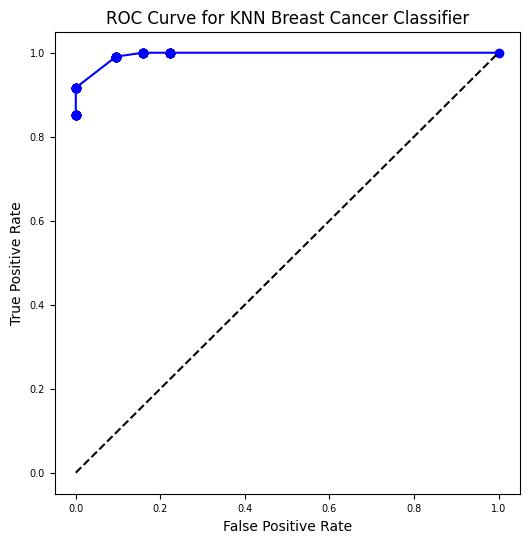

In [111]:
plt.figure(figsize=(6,6))
plt.plot(fpr_list, tpr_list, marker='o', linestyle='-', color='blue')
plt.plot([0,1], [0,1], 'k--')  # Random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for KNN Breast Cancer Classifier")
plt.show()

In [113]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

In [115]:
data = kf.split(bc.data)

In [121]:
scores = []

for train_index,test_index in data:
    X_train, y_train = bc.data[train_index],bc.target[train_index]
    X_test, y_test = bc.data[test_index], bc.target[test_index]

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train,y_train)
    score = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)


NameError: name 'accuracy_score' is not defined